# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Amelia Vega
- **Email:** cdcc200d6x2237@student.devacademy.id
- **ID Dicoding:** CDCC200D6X2237

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (`weathersit`), suhu (`temp`), dan kelembaban (`hum`) terhadap jumlah penyewaan sepeda harian (`cnt`) pada tahun 2011–2012?

**Keterangan:**

- **Specific**: Fokus pada pengaruh variabel lingkungan yaitu kondisi cuaca, suhu, dan kelembaban terhadap jumlah penyewaan sepeda harian.
- **Measurable**: Menggunakan variabel yang dapat diukur seperti `cnt`, `temp`, `hum`, serta kategori `weathersit`.
- **Action-Oriented**: Hasil analisis dapat digunakan untuk menentukan strategi operasional seperti penyesuaian jumlah sepeda atau promosi berdasarkan kondisi cuaca.
- **Relevant**: Faktor cuaca sangat berpengaruh terhadap perilaku pengguna dalam menggunakan layanan bike sharing.
- **Time-bound**: Analisis dibatasi pada periode tahun 2011–2012.


**Pertanyaan 2:** Bagaimana perbedaan rata-rata jumlah penyewaan sepeda (`cnt`) pada setiap musim (`season`) dan bulan (`mnth`) selama periode 2011–2012?

**Keterangan:**

- **Specific**: Fokus pada perbandingan jumlah penyewaan sepeda berdasarkan musim dan bulan.
- **Measurable**: Menggunakan rata-rata jumlah penyewaan (`cnt`) yang dapat dihitung dan dibandingkan antar kategori waktu.
- **Action-Oriented**: Insight dapat digunakan untuk perencanaan kapasitas, distribusi sepeda, dan strategi promosi.
- **Relevant**: Pola musiman penting untuk memahami fluktuasi permintaan dalam layanan bike sharing.
- **Time-bound**: Analisis dilakukan pada periode tahun 2011–2012.

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from google.colab import drive

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

#### Load df Bike Sharing (Day)

In [4]:
# Load dataset
day_df = pd.read_csv('/content/day.csv')
hour_df = pd.read_csv('/content/hour.csv')

# Preview data
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset terdiri dari dua jenis data, yaitu data harian (day.csv) dan data per jam (hour.csv), yang mencatat jumlah penyewaan sepeda pada tahun 2011–2012. Dataset day.csv dipilih sebagai data utama karena lebih sederhana dan sudah cukup merepresentasikan pola penyewaan sepeda untuk analisis.
- Dataset berhasil dimuat dengan baik dan terdiri dari beberapa variabel seperti `instant`, `dteday`, `season`, `weathersit`, `temp`, `hum`, `casual`, `registered`, dan `cnt`.
- Kolom `cnt` merupakan total jumlah penyewaan sepeda yang merupakan gabungan dari pengguna casual dan registered.
- Data menunjukkan bahwa setiap baris merepresentasikan jumlah penyewaan sepeda per hari dengan berbagai faktor pendukung seperti kondisi cuaca dan waktu.
- Kolom `dteday` masih bertipe object (string) sehingga perlu dikonversi menjadi tipe datetime pada tahap cleaning.
- Beberapa variabel seperti `season` dan `weathersit` masih dalam bentuk kode numerik, sehingga perlu diubah menjadi label yang lebih deskriptif agar mudah dianalisis.

### Assessing Data

#### Identifying Data Type & Structure Problem

In [5]:
# Cek struktur data
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Berdasarkan hasil pengecekan struktur data, dataset memiliki 731 baris dan 16 kolom dengan mayoritas tipe data numerik yang sudah sesuai. Namun, kolom `dteday` masih bertipe object sehingga perlu dikonversi menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.

#### Identifying Missing Values Problem

In [6]:
# Cek missing values
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Berdasarkan hasil pengecekan, tidak ditemukan missing value pada seluruh kolom dalam dataset, sehingga data dapat digunakan secara langsung tanpa perlu penanganan nilai kosong.

#### Identifying Duplicate Data Problem

In [7]:
# Cek data duplikat
day_df.duplicated().sum()

np.int64(0)

Hasil pengecekan menunjukkan bahwa tidak terdapat data duplikat dalam dataset, sehingga setiap baris data merupakan observasi yang unik.

#### Identifying Inacurrate, Inconsistent, Invalid Value Problem

In [8]:
# Cek statistik deskriptif
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Berdasarkan statistik deskriptif, seluruh variabel numerik memiliki nilai yang berada dalam **rentang wajar**, sehingga tidak ditemukan **invalid value**. Hasil pengecekan menunjukkan bahwa nilai `cnt` merupakan hasil penjumlahan dari `casual` dan `registered`, sehingga tidak ditemukan **inaccurate value** dalam dataset.

In [9]:
# Cek nilai unik pada kolom kategorikal
print("Season:", day_df['season'].unique())
print("Weather:", day_df['weathersit'].unique())

Season: [1 2 3 4]
Weather: [2 1 3]


Kolom `season` dan `weathersit` masih berupa **kode numerik**, sehingga perlu diubah menjadi label kategorikal yang lebih deskriptif agar mudah dipahami dalam analisis.

#### Identifying Outlier Problem

In [10]:
# Menghitung Q1 dan Q3
Q1 = day_df['cnt'].quantile(0.25)
Q3 = day_df['cnt'].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3152.0
Q3: 5956.0
IQR: 2804.0
Lower Bound: -1054.0
Upper Bound: 10162.0


In [11]:
# Menampilkan data yang termasuk outlier
outliers = day_df[(day_df['cnt'] < lower_bound) | (day_df['cnt'] > upper_bound)]

print("Jumlah outlier:", len(outliers))
outliers.head()

Jumlah outlier: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


Berdasarkan metode IQR yang telah dilakukan, tidak ditemukan adanya outlier pada variabel numerik, sehingga data tidak memerlukan penanganan khusus terkait nilai ekstrem.

**Steps to Take:**
Berdasarkan hasil assessing data, langkah-langkah yang akan dilakukan pada tahap data cleaning adalah sebagai berikut:

- Mengubah tipe data kolom `dteday` dari object menjadi datetime agar dapat digunakan dalam analisis berbasis waktu
- Mengubah nilai kategorikal pada kolom `season` dan `weathersit` dari kode numerik menjadi label yang lebih deskriptif

**Insight:** (Opsional)

Berdasarkan hasil proses assessing data yang telah dilakukan, diperoleh beberapa temuan sebagai berikut:

* Ditemukan **Kesalahan Tipe data**, yaitu: Kolom `dteday` masih bertipe **object**, sehingga perlu dikonversi menjadi tipe datetime.

* Tidak ditemukan **missing value** pada seluruh kolom dataset, sehingga data dapat langsung digunakan tanpa perlu proses penanganan nilai kosong.

* Tidak terdapat **data duplikat**, sehingga tidak diperlukan proses penghapusan data duplilat.

* Berdasarkan statistik deskriptif, seluruh variabel numerik memiliki nilai yang berada dalam **rentang wajar**, sehingga tidak ditemukan **invalid value**.

* Hasil pengecekan menunjukkan bahwa nilai `cnt` merupakan hasil penjumlahan dari `casual` dan `registered`, sehingga tidak ditemukan **inaccurate value** dalam dataset.

* Kolom `season` dan `weathersit` masih berupa **kode numerik**, sehingga perlu diubah menjadi label kategorikal yang lebih deskriptif agar mudah dipahami dalam analisis.

* Berdasarkan pengecekan menggunakan **IQR Method** pada variabel `cnt`, tidak ditemukan **outlier** dalam dataset. Hal ini menunjukkan bahwa distribusi data relatif stabil dan tidak terdapat nilai ekstrem yang menyimpang secara signifikan dari mayoritas data.


* Secara umum, dataset sudah dalam kondisi cukup baik, namun tetap memerlukan proses **data cleaning** untuk meningkatkan kualitas dan kemudahan interpretasi data pada tahap analisis selanjutnya.



### Cleaning Data

#### Fixing Data Type Problem

In [12]:
# Convert dteday ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [13]:
# Cek struktur data
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

Kolom `dteday` telah berhasil dikonversi menjadi tipe **datetime**, sehingga dapat digunakan untuk analisis berbasis waktu


#### Fixing Labeling Problem

In [14]:
# Mapping season
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

day_df['season'] = day_df['season'].map(season_map)

In [15]:
# Mapping weathersit
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

day_df['weathersit'] = day_df['weathersit'].map(weather_map)

In [16]:
# Cek hasil cleaning
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Kolom `season` dan `weathersit` telah diubah dari kode numerik menjadi **label kategorikal yang lebih deskriptif**, sehingga lebih mudah dipahami

In [17]:
# Download data hasil cleaning

day_df.to_csv("main_data.csv", index=False)
files.download("main_data.csv")

print('Download berhasil')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download berhasil


**Insight:** (Opsional)

Setelah dilakukan proses data cleaning, diperoleh beberapa perubahan sebagai berikut:

* Kolom `dteday` telah berhasil dikonversi menjadi tipe **datetime**, sehingga dapat digunakan untuk analisis berbasis waktu
* Kolom `season` dan `weathersit` telah diubah dari kode numerik menjadi **label kategorikal yang lebih deskriptif**, sehingga lebih mudah dipahami
* Data menjadi lebih **konsisten dan informatif**, sehingga memudahkan proses eksplorasi dan visualisasi
* Dataset telah siap digunakan untuk tahap selanjutnya, yaitu **Exploratory Data Analysis (EDA)**


## Exploratory Data Analysis (EDA)

### Explore the Effect of Weather and Environmental Factors on Bike Rentals


In [18]:
# Rata-rata penyewaan berdasarkan kondisi cuaca
day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

,cnt
weathersit,
Clear,4876.786177
Mist,4035.862348
Light Rain/Snow,1803.285714


Berdasarkan kondisi cuaca, diketahui bahwa rata-rata penyewaan tertinggi terjadi pada kondisi Clear (4876), diikuti oleh Mist (4035), dan terendah pada kondisi Light Rain/Snow (1803).

In [19]:
# Rata-rata penyewaan berdasarkan season
day_df.groupby('season')['cnt'].mean().sort_values(ascending=False)

,cnt
season,
Fall,5644.303191
Summer,4992.331522
Winter,4728.162921
Spring,2604.132597


Berdasarkan musim, rata-rata penyewaan tertinggi terjadi pada musim Fall (5644), diikuti oleh Summer (4992) dan Winter (4728), sedangkan yang terendah terjadi pada Spring (2604).

In [20]:
# Korelasi antara variabel numerik
day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()

,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.234545
cnt,0.627494,0.631066,-0.100659,-0.234545,1.000000


- Variabel temp (0.63) dan atemp (0.63) memiliki korelasi positif yang cukup kuat terhadap jumlah penyewaan (cnt)

- Variabel hum (-0.10) memiliki korelasi negatif yang lemah, menunjukkan bahwa kelembaban tidak terlalu berpengaruh signifikan terhadap jumlah penyewaan.

- Variabel windspeed (-0.23) memiliki korelasi negatif sedang, yang menunjukkan bahwa semakin tinggi kecepatan angin, jumlah penyewaan cenderung menurun.

#### Explore Seasonal and Monthly Trends in Bike Rentals


In [21]:
# Rata-rata penyewaan per bulan
day_df.groupby('mnth')['cnt'].mean()

,cnt
mnth,
1,2176.338710
2,2655.298246
3,3692.258065
4,4484.900000
5,5349.774194
6,5772.366667
7,5563.677419
8,5664.419355
9,5766.516667


Rata-rata penyewaan sepeda meningkat dari awal tahun dan mencapai puncaknya pada bulan Juni hingga September (sekitar 5700-an)dan menurun kembali pada akhir tahun, dengan nilai terendah pada bulan Januari (2176)

In [22]:
# Rata-rata penyewaan per tahun
day_df.groupby('yr')['cnt'].mean()

,cnt
yr,
0,3405.761644
1,5599.934426


Tahun 2012 (5599) memiliki rata-rata penyewaan yang jauh lebih tinggi dibandingkan tahun 2011 (3405)

In [23]:
# Kombinasi musim dan tahun
day_df.groupby(['yr', 'season'])['cnt'].mean()

yr  season
0   Fall      4464.361702
    Spring    1666.666667
    Summer    3775.173913
    Winter    3664.460674
1   Fall      6824.244681
    Spring    3531.296703
    Summer    6209.489130
    Winter    5791.865169
Name: cnt, dtype: float64

Semua musim mengalami peningkatan signifikan pada tahun 2012 dibandingkan 2011. Musim Fall di tahun 2012 (6824) menjadi periode dengan penyewaan tertinggi

**Insight:** (Opsional)

**pertanyaan 1**

* Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Rata-rata penyewaan tertinggi terjadi pada kondisi **Clear (4876)**, diikuti oleh **Mist (4035)**, dan terendah pada kondisi **Light Rain/Snow (1803)**. Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, maka jumlah penyewaan sepeda cenderung menurun secara signifikan.

* Berdasarkan musim, rata-rata penyewaan tertinggi terjadi pada musim **Fall (5644)**, diikuti oleh **Summer (4992)** dan **Winter (4728)**, sedangkan yang terendah terjadi pada **Spring (2604)**. Hal ini menunjukkan adanya pengaruh musim terhadap tingkat penggunaan sepeda.

* Hasil analisis korelasi menunjukkan bahwa:

  * Variabel **temp (0.63)** dan **atemp (0.63)** memiliki korelasi positif yang cukup kuat terhadap jumlah penyewaan (`cnt`), yang berarti semakin tinggi suhu, maka jumlah penyewaan cenderung meningkat.
  * Variabel **hum (-0.10)** memiliki korelasi negatif yang lemah, menunjukkan bahwa kelembaban tidak terlalu berpengaruh signifikan terhadap jumlah penyewaan.
  * Variabel **windspeed (-0.23)** memiliki korelasi negatif sedang, yang menunjukkan bahwa semakin tinggi kecepatan angin, jumlah penyewaan cenderung menurun.

* Berdasarkan hasil tersebut, dapat disimpulkan bahwa faktor lingkungan seperti **cuaca dan suhu** memiliki pengaruh yang cukup kuat terhadap permintaan penyewaan sepeda, sehingga dapat digunakan sebagai dasar dalam pengambilan keputusan operasional.

**pertanyaan 2**

* Rata-rata penyewaan sepeda per bulan menunjukkan pola yang jelas, yaitu:

  * Penyewaan meningkat dari awal tahun dan mencapai puncaknya pada bulan **Juni hingga September** (sekitar 5700-an)
  * Penyewaan menurun kembali pada akhir tahun, dengan nilai terendah pada bulan **Januari (2176)**

* Hal ini menunjukkan adanya pola **musiman**, di mana permintaan sepeda cenderung tinggi pada pertengahan tahun dan rendah pada awal serta akhir tahun.

* Berdasarkan perbandingan tahunan, terlihat bahwa:

  * Tahun **2012 (5599)** memiliki rata-rata penyewaan yang jauh lebih tinggi dibandingkan tahun **2011 (3405)**
  * Hal ini menunjukkan adanya peningkatan penggunaan sepeda dari tahun ke tahun

* Analisis kombinasi musim dan tahun menunjukkan bahwa:

  * Semua musim mengalami peningkatan signifikan pada tahun 2012 dibandingkan 2011
  * Musim **Fall di tahun 2012 (6824)** menjadi periode dengan penyewaan tertinggi

* Berdasarkan hasil tersebut, dapat disimpulkan bahwa terdapat pola **tren meningkat dari tahun ke tahun** serta **pola musiman yang kuat**, yang dapat dimanfaatkan untuk strategi perencanaan bisnis dan operasional.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca, suhu, dan kelembaban terhadap jumlah penyewaan sepeda selama periode 2011-2012?

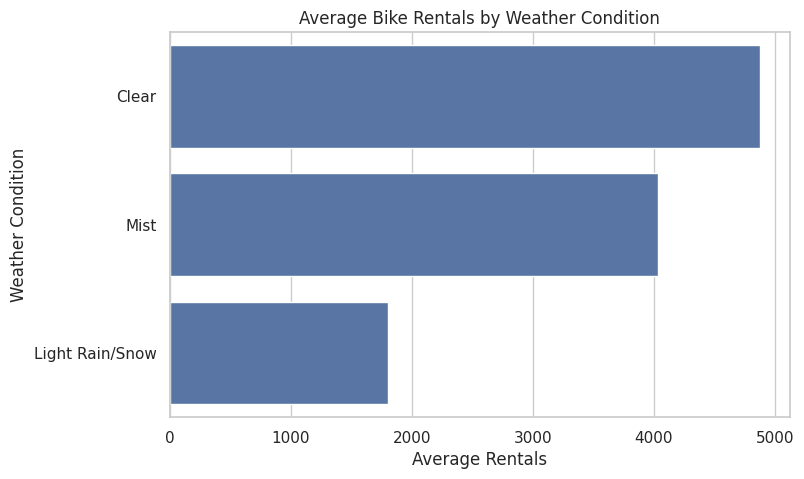

In [24]:
#Bar Chart rata-rata penyewaan sepeda berdasarkan kondisi cuaca

order = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False).index

plt.figure(figsize=(8,5))
sns.barplot(
    data=day_df,
    y='weathersit',
    x='cnt',
    estimator='mean',
    order=order,
    errorbar=None
)

plt.title('Average Bike Rentals by Weather Condition')
plt.xlabel('Average Rentals')
plt.ylabel('Weather Condition')
plt.show()

Berdasarkan visualisasi bar chart, kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Penyewaan tertinggi terjadi pada kondisi Clear, diikuti oleh Mist, dan terendah pada kondisi Light Rain/Snow.

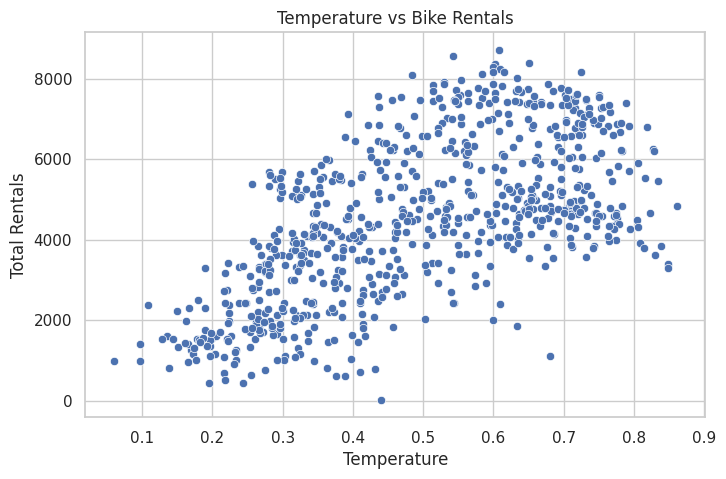

In [25]:
# Scatterplot pengaruh suhu terhadap jumlah penyewaan sepedah

plt.figure(figsize=(8,5))
sns.scatterplot(data=day_df, x='temp', y='cnt')

plt.title('Temperature vs Bike Rentals')
plt.xlabel('Temperature')
plt.ylabel('Total Rentals')
plt.show()

Scatter plot antara suhu (`temp`) dan jumlah penyewaan (`cnt`) menunjukkan adanya hubungan positif, di mana semakin tinggi suhu, jumlah penyewaan sepeda cenderung meningkat.

### Pertanyaan 2: Bagaimana pola penyewaan sepeda berdasarkan musim dan bulan pada periode 2011–2012?

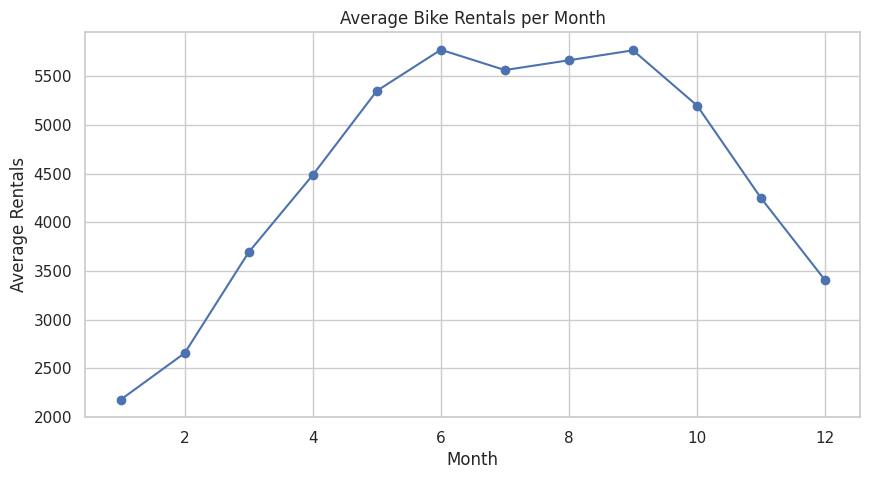

In [26]:
# Line chart rata-rata penyewaan sepedah perbulan

monthly_avg = day_df.groupby('mnth')['cnt'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.title('Average Bike Rentals per Month')
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.show()

Visualisasi line chart menunjukkan adanya pola musiman yang jelas, di mana jumlah penyewaan sepeda meningkat dari awal tahun dan mencapai puncaknya pada bulan Juni hingga September, kemudian menurun kembali pada akhir tahun

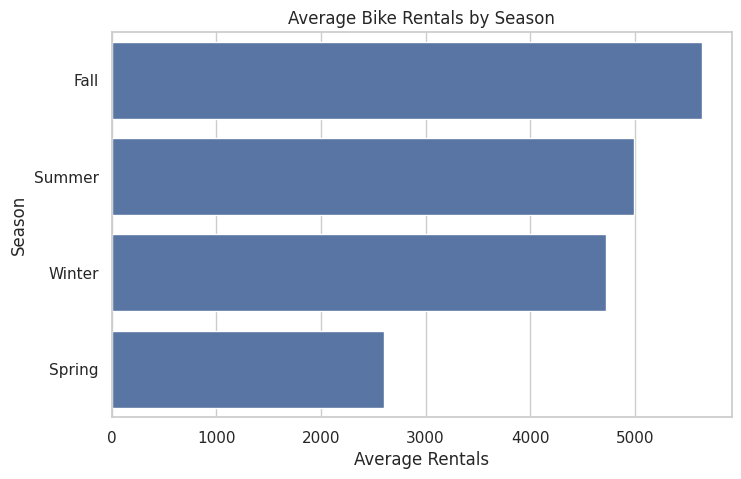

In [27]:
#Bar chart rata-rata penyewaan sepeda berdasarkan musim

order = day_df.groupby('season')['cnt'].mean().sort_values(ascending=False).index

plt.figure(figsize=(8,5))
sns.barplot(
    data=day_df,
    y='season',
    x='cnt',
    estimator='mean',
    order=order,
    errorbar=None
)

plt.title('Average Bike Rentals by Season')
plt.xlabel('Average Rentals')
plt.ylabel('Season')
plt.show()

Berdasarkan bar chart, musim Fall memiliki rata-rata penyewaan tertinggi, diikuti oleh Summer dan Winter, sedangkan musim Spring memiliki jumlah penyewaan terendah.

**Insight:** (Opsional)

**Pertanyaan 1**
* Berdasarkan visualisasi bar chart, kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Penyewaan tertinggi terjadi pada kondisi **Clear**, diikuti oleh **Mist**, dan terendah pada kondisi **Light Rain/Snow**. Hal ini menunjukkan bahwa pengguna cenderung menyewa sepeda saat cuaca cerah dan menghindari kondisi cuaca buruk.

* Scatter plot antara suhu (`temp`) dan jumlah penyewaan (`cnt`) menunjukkan adanya **hubungan positif**, di mana semakin tinggi suhu, jumlah penyewaan sepeda cenderung meningkat. Hal ini terlihat dari pola titik yang membentuk tren naik.

* Berdasarkan hasil visualisasi, dapat disimpulkan bahwa faktor lingkungan seperti **cuaca dan suhu** memiliki pengaruh yang kuat terhadap jumlah penyewaan sepeda.

**Pertanyaan 2**

* Visualisasi line chart menunjukkan adanya pola musiman yang jelas, di mana jumlah penyewaan sepeda meningkat dari awal tahun dan mencapai puncaknya pada bulan **Juni hingga September**, kemudian menurun kembali pada akhir tahun.

* Hal ini mengindikasikan bahwa terdapat periode tertentu dengan permintaan tinggi, yang kemungkinan dipengaruhi oleh kondisi cuaca yang lebih mendukung aktivitas luar ruangan.

* Berdasarkan bar chart, musim **Fall** memiliki rata-rata penyewaan tertinggi, diikuti oleh **Summer** dan **Winter**, sedangkan musim **Spring** memiliki jumlah penyewaan terendah.

* Pola ini menunjukkan bahwa musim memiliki pengaruh yang cukup signifikan terhadap tingkat penggunaan sepeda, dengan kecenderungan pengguna lebih aktif pada musim dengan kondisi lingkungan yang lebih nyaman.

* Secara keseluruhan, hasil visualisasi menunjukkan adanya **pola musiman yang kuat**, yang dapat dimanfaatkan untuk perencanaan operasional dan strategi bisnis.


## Analisis Lanjutan (Opsional)

### Analisis Lanjutan: Clustering Berdasarkan Tingkat Penyewaan Sepeda

Setelah melakukan eksplorasi data dan visualisasi, diketahui bahwa faktor lingkungan seperti cuaca, suhu, serta pola musiman memiliki pengaruh terhadap jumlah penyewaan sepeda. Untuk memperdalam pemahaman terhadap pola permintaan tersebut, dilakukan analisis lanjutan menggunakan metode **clustering sederhana (manual grouping)** dengan kategori sebagai berikut:

- Low demand : Jumlah penyewaan kurang dari 3000 dalam sehari
- Medium demand : Jumlah penyewaan berada diantara 3000 hingga 6000 dalam sehari
- High demand : Jumlah penyewaan lebih dari 6000 dalam sehari

Metode ini digunakan untuk mengelompokkan data berdasarkan tingkat penyewaan sepeda (`cnt`) ke dalam beberapa kategori, sehingga dapat memberikan gambaran yang lebih terstruktur mengenai kondisi permintaan.

Tujuan dari analisis ini adalah:

* Mengidentifikasi kategori permintaan (rendah, sedang, tinggi)
* Memahami karakteristik setiap kategori berdasarkan faktor lingkungan
* Menghubungkan pola permintaan dengan kondisi cuaca dan suhu
* Memberikan dasar dalam pengambilan keputusan operasional yang lebih tepat


In [28]:
# Membuat kategori berdasarkan jumlah penyewaan
def categorize_demand(cnt):
    if cnt < 3000:
        return 'Low'
    elif cnt < 6000:
        return 'Medium'
    else:
        return 'High'

day_df['demand_category'] = day_df['cnt'].apply(categorize_demand)

# Melihat jumlah data tiap kategori
day_df['demand_category'].value_counts()

,count
demand_category,
Medium,379
High,180
Low,172


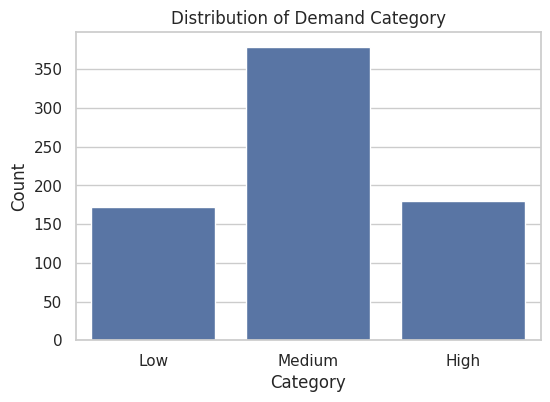

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=day_df, x='demand_category')

plt.title('Distribution of Demand Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

Distribusi kategori menunjukkan bahwa mayoritas hari berada pada kategori Medium (379 hari), diikuti oleh High (180 hari) dan Low (172 hari).

In [30]:
# Rata-rata berdasarkan kategori
day_df.groupby('demand_category')[['temp', 'hum', 'windspeed', 'cnt']].mean()

,temp,hum,windspeed,cnt
demand_category,,,,
High,0.623208,0.607894,0.168339,7060.077778
Low,0.303237,0.640134,0.220726,1859.633721
Medium,0.521879,0.631838,0.187281,4490.786280


Rata-rata jumlah penyewaan (`cnt`) meningkat secara signifikan dari kategori Low (±1859), Medium (±4491), hingga High (±7060).



In [31]:
day_df.groupby('demand_category')['weathersit'].value_counts()

demand_category  weathersit     
High             Clear              140
                 Mist                40
Low              Clear               78
                 Mist                75
                 Light Rain/Snow     19
Medium           Clear              245
                 Mist               132
                 Light Rain/Snow      2
Name: count, dtype: int64

Seluruh Kategori Hdemand didominasi oleh kondisi Clear

**Insight**

Berdasarkan hasil analisis lanjutan menggunakan metode clustering (manual grouping), diperoleh beberapa temuan sebagai berikut:

* Distribusi kategori menunjukkan bahwa mayoritas hari berada pada kategori **Medium (379 hari)**, diikuti oleh **High (180 hari)** dan **Low (172 hari)**. Hal ini menunjukkan bahwa permintaan penyewaan sepeda cenderung stabil pada tingkat menengah, dengan beberapa periode lonjakan dan penurunan.

* Rata-rata jumlah penyewaan (`cnt`) meningkat secara signifikan dari kategori **Low (±1859)**, **Medium (±4491)**, hingga **High (±7060)**. Hal ini menunjukkan bahwa pengelompokan yang dilakukan berhasil merepresentasikan tingkat permintaan dengan baik.

* Dari sisi faktor lingkungan:

  * Kategori **High demand** memiliki rata-rata suhu tertinggi (~0.62), menunjukkan bahwa suhu yang lebih tinggi berkaitan dengan peningkatan jumlah penyewaan
  * Kategori **Low demand** memiliki suhu terendah (~0.30), yang mengindikasikan bahwa kondisi suhu rendah cenderung menurunkan minat penyewaan
  * Kelembaban (`hum`) tidak menunjukkan perbedaan signifikan antar kategori, sehingga pengaruhnya relatif kecil
  * Kecepatan angin (`windspeed`) cenderung lebih tinggi pada kategori **Low**, yang mengindikasikan bahwa angin kencang dapat mengurangi jumlah penyewaan

* Berdasarkan kondisi cuaca:

  * Kategori **High demand** didominasi oleh kondisi **Clear (140 hari)**, menunjukkan bahwa cuaca cerah sangat mendukung peningkatan penyewaan
  * Kategori **Low demand** memiliki lebih banyak variasi cuaca, termasuk kondisi **Light Rain/Snow**, yang berkontribusi terhadap rendahnya jumlah penyewaan
  * Kategori **Medium demand** juga didominasi oleh cuaca **Clear**, namun dengan jumlah yang lebih besar dibanding kategori lainnya

* Secara keseluruhan, hasil analisis ini memperkuat temuan sebelumnya bahwa **cuaca dan suhu merupakan faktor utama yang memengaruhi tingkat permintaan penyewaan sepeda**, serta memberikan gambaran yang lebih jelas mengenai kondisi-kondisi yang menghasilkan permintaan tinggi maupun rendah.


## Conclusion & Recommendation


* **Conclusion pertanyaan 1:**
  Kondisi cuaca dan suhu terbukti memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Penyewaan tertinggi terjadi pada kondisi cuaca cerah (*Clear*) dan suhu yang lebih tinggi, sedangkan kondisi cuaca buruk seperti hujan atau salju ringan secara signifikan menurunkan jumlah penyewaan. Kelembaban dan kecepatan angin memiliki pengaruh yang relatif lebih kecil dibandingkan faktor lainnya.

* **Conclusion pertanyaan 2:**
  Terdapat pola musiman yang jelas dalam penyewaan sepeda, di mana jumlah penyewaan meningkat pada pertengahan tahun (sekitar bulan Juni hingga September) dan menurun pada awal serta akhir tahun. Selain itu, terjadi peningkatan signifikan jumlah penyewaan dari tahun 2011 ke 2012, yang menunjukkan adanya tren pertumbuhan penggunaan layanan bike sharing.


**Rekomendasi Action Item:**

* Menyediakan lebih banyak sepeda dan meningkatkan kesiapan operasional pada periode dengan **permintaan tinggi**, terutama saat musim *Fall* dan bulan Juni–September
* Mengoptimalkan promosi atau diskon pada periode dengan **permintaan rendah** (awal dan akhir tahun) untuk meningkatkan jumlah penyewaan
* Mengintegrasikan **informasi cuaca** dalam sistem operasional atau aplikasi, sehingga pengguna dapat merencanakan penyewaan dengan lebih baik
* Mengembangkan strategi khusus untuk menghadapi kondisi cuaca buruk, seperti penyediaan promo atau layanan tambahan untuk menjaga tingkat penggunaan
